# Challenge 1 – Context-Aware Hierarchical Robot Control: Feasibility Prototype

**Question:** Does an initial *environment-understanding* phase (Video-LLM) improve robot operation in an unseen home, **without retraining** any model?

**Pipeline:** `Perception (Video-LLM on walkthrough video) ➔ Reasoning (VLM + task) ➔ Environment Grounding (structured JSON context) ➔ Low-level policy (actions)`

| Component | Used here |
|---|---|
| Pre-trained Video-LLM / VLM | **Qwen2.5-VL-3B-Instruct** (video understanding + 2-D grounding), frozen |
| High-level reasoning | Same VLM, prompted with task + scene summary |
| Low-level policy | Scripted pick-and-place controller that consumes the context (stand-in for a learned motor policy) |
| Evaluator (independent) | **OWLv2** open-vocabulary detector gives the pseudo ground-truth box of the target |

**Experiment:** several short videos of different homes/rooms (varied layout & clutter) × two lighting conditions (normal, dim).
- **Baseline** – robot acts with no scene context: uses its *training-home preset* grasp location and counter height.
- **Ours** – robot first watches the scene, then grounds the task and passes structured context to the policy.

**Metrics:** grasp success (planned grasp point lies inside the target's true box) and IoU of the grounded box.

> Runtime: Colab GPU (T4 is enough). Runtime ➔ Change runtime type ➔ GPU.

In [1]:
!pip -q install -U "transformers>=4.49" accelerate qwen-vl-utils opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 16.3 MB/s eta 0:00:00


In [2]:
import torch, json, re, cv2, numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib.patches as patches
from PIL import Image, ImageEnhance
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor, pipeline
from qwen_vl_utils import process_vision_info, smart_resize

MODEL_ID = "Qwen/Qwen2.5-VL-3B-Instruct"
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(MODEL_ID, torch_dtype="auto", device_map="auto", attn_implementation="sdpa").eval()
processor = AutoProcessor.from_pretrained(MODEL_ID)
detector = pipeline("zero-shot-object-detection", model="google/owlv2-base-patch16-ensemble", device=0)  # evaluator only
print("GPU:", torch.cuda.get_device_name(0))

config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/65.4k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

...

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/67.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/121 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

GPU: Tesla T4


## 1. Data – unseen homes
Upload 2–4 short (5–20 s) phone videos slowly panning over different kitchens / rooms (different layouts, clutter, counter heights).
Then edit `TASKS` so each video has a task and a target object that is visible in it.

In [3]:
from google.colab import files
uploaded = list(files.upload().keys())
print(uploaded)

Saving IMG_2133.MOV to IMG_2133.MOV
Saving IMG_2132.MOV to IMG_2132.MOV
['IMG_2133.MOV', 'IMG_2132.MOV']


In [4]:
# EDIT: one entry per uploaded video ->  filename: (task instruction, target object name)
TASKS = {
    uploaded[0]: ("Pick up the cup and place it in the sink", "cup"),
    uploaded[1]: ("Pick up the bottle and put it on the table", "bottle"),
    # uploaded[2]: ("Pick up the remote and put it on the sofa", "remote"),
}
LIGHTING = {"normal": 1.0, "dim": 0.35}   # simulated dynamic lighting (brightness factor)

## 2. Helpers – Video-LLM call, frame sampling, JSON parsing

In [5]:
MAX_PIX = 640 * 28 * 28

def ask(content, max_new_tokens=768):
    msgs = [{"role": "user", "content": content}]
    text = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    imgs, vids = process_vision_info(msgs)
    inputs = processor(text=[text], images=imgs, videos=vids, padding=True, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    return processor.batch_decode(out[:, inputs.input_ids.shape[1]:], skip_special_tokens=True)[0]

def parse_json(s):
    s = re.sub(r"```(json)?", "", s)
    m = re.search(r"[\[{].*[\]}]", s, re.S)
    try: return json.loads(m.group(0)) if m else None
    except Exception: return None

def load_frames(path, n=8):
    cap = cv2.VideoCapture(path); N = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)); frames = []
    for i in np.linspace(0, N - 1, n).astype(int):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i); ok, f = cap.read()
        if ok: frames.append(Image.fromarray(cv2.cvtColor(f, cv2.COLOR_BGR2RGB)))
    if len(frames) % 2: frames.append(frames[-1])          # Qwen needs an even number of frames
    return frames

def prep(img):  # resize to Qwen's native grid so predicted pixel boxes map 1:1 to this image
    h, w = smart_resize(img.height, img.width, factor=28, max_pixels=MAX_PIX)
    return img.resize((w, h))

def iou(a, b):
    if a is None or b is None: return 0.0
    x1, y1, x2, y2 = max(a[0], b[0]), max(a[1], b[1]), min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    return inter / ((a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter + 1e-6)

def owl_box(img, label):
    r = detector(img, candidate_labels=[label])
    if not r: return None, 0.0
    b = max(r, key=lambda d: d["score"])
    return [b["box"][k] for k in ("xmin", "ymin", "xmax", "ymax")], b["score"]

## 3. The hierarchy
**Stage 1 – Scene perception (Video-LLM):** watch the whole walkthrough, summarise layout, surfaces, objects, obstacles, lighting, clutter.<br>
**Stage 2 – High-level reasoning:** given task + scene summary + current view, locate target/destination, obstacles, surface height, and a step plan.<br>
**Stage 3 – Environment grounding:** convert the answer into a structured context (pixel grasp point, surface height, keep-out boxes).<br>
**Stage 4 – Low-level policy:** turns context into an action sequence.

In [6]:
def scene_perception(frames):
    prompt = ('You are the perception module of a home robot that just entered an UNSEEN home. Watch the video and return ONLY JSON: '
              '{"room_type": str, "lighting": "bright|dim|mixed", "clutter": "low|medium|high", '
              '"surfaces": [{"name": str, "height": "low|counter|high"}], "objects": [str], "obstacles": [str]}')
    return parse_json(ask([{"type": "video", "video": frames, "max_pixels": 360 * 420}, {"type": "text", "text": prompt}]))

def reasoning(view, task, scene):
    prompt = (f'Task: "{task}".\nScene context from the robot\'s exploration: {json.dumps(scene)}\n'
              'Using the image, ground the task. Return ONLY JSON: {"target": {"label": str, "bbox_2d": [x1,y1,x2,y2]}, '
              '"destination": {"label": str, "bbox_2d": [x1,y1,x2,y2] or null}, "obstacles": [{"label": str, "bbox_2d": [x1,y1,x2,y2]}], '
              '"surface_height": "low|counter|high", "plan": [str]}')
    return parse_json(ask([{"type": "image", "image": view, "max_pixels": MAX_PIX}, {"type": "text", "text": prompt}]))

HEIGHT_M = {"low": 0.45, "counter": 0.90, "high": 1.50}
PRESET = {"grasp_px": (0.5, 0.6), "surface_z": 0.90}      # what the robot learned in its training home

def grounding(r, W, H):
    """Environment grounding: VLM answer -> structured context for the motor policy (falls back to preset if unusable)."""
    try:
        b = [float(v) for v in r["target"]["bbox_2d"]]
        b = [min(max(b[0], 0), W), min(max(b[1], 0), H), min(max(b[2], 0), W), min(max(b[3], 0), H)]
        return {"target_box": b, "grasp_px": ((b[0]+b[2]) / 2, (b[1]+b[3]) / 2),
                "surface_z": HEIGHT_M.get(r.get("surface_height"), 0.9),
                "keep_out": [o["bbox_2d"] for o in r.get("obstacles", []) if "bbox_2d" in o],
                "place": (r.get("destination") or {}).get("label")}
    except Exception:
        return baseline_context(W, H)

def baseline_context(W, H):
    return {"target_box": None, "grasp_px": (PRESET["grasp_px"][0] * W, PRESET["grasp_px"][1] * H),
            "surface_z": PRESET["surface_z"], "keep_out": [], "place": None}

def low_level_policy(ctx):
    """Stand-in motor policy: same code for baseline and ours - only the context differs."""
    (u, v), z = ctx["grasp_px"], ctx["surface_z"]
    return [("move_above", round(u), round(v), z + 0.15), ("descend", round(u), round(v), z + 0.02), ("close_gripper",),
            ("lift", z + 0.25), ("avoid", len(ctx["keep_out"]), "boxes"), ("move_to", ctx["place"] or "preset_drop"), ("open_gripper",)]

## 4. Run the feasibility test (baseline vs. context-aware) on every home × lighting

In [7]:
rows, viz = [], []
for vid, (task, target) in TASKS.items():
    frames = load_frames(vid)
    scene = scene_perception(frames)                                  # Stage 1 (once per home, normal light)
    print(f"\n=== {vid} | task: {task}\nScene context: {json.dumps(scene, indent=1)}")

    # pick the frame where the target is most visible; its OWLv2 box is the pseudo ground truth
    cands = [(owl_box(prep(f), target), prep(f)) for f in frames]
    (gt, gt_score), view = max(cands, key=lambda c: c[0][1])
    W, H = view.size

    for cond, k in LIGHTING.items():
        img = ImageEnhance.Brightness(view).enhance(k)
        r = reasoning(img, task, scene)                               # Stage 2
        ctx_ours, ctx_base = grounding(r, W, H), baseline_context(W, H)   # Stage 3
        for name, ctx in [("baseline (no context)", ctx_base), ("context-aware (ours)", ctx_ours)]:
            u, v = ctx["grasp_px"]
            ok = gt is not None and gt[0] <= u <= gt[2] and gt[1] <= v <= gt[3]
            rows.append({"home": vid, "lighting": cond, "method": name, "grasp_success": int(ok), "IoU": round(iou(ctx["target_box"], gt), 3)})
        if cond == "normal":
            print("Plan:", (r or {}).get("plan")); print("Actions:", low_level_policy(ctx_ours))  # Stage 4
        viz.append((f"{vid} | {cond}", img, gt, ctx_base, ctx_ours))

df = pd.DataFrame(rows); df

[transformers] Qwen2VL video processing does not apply the per-frame pixel cap the reference implementation (qwen-vl-utils) applies, so some videos cost far more tokens than they would there. In v5.22 the capped behavior will become the default and `cap_pixels_per_frame` will be removed. Pass `cap_pixels_per_frame=True` to adopt the reference behavior now, or `False` to keep the current behavior and silence this warning.



=== IMG_2133.MOV | task: Pick up the cup and place it in the sink
Scene context: {
 "room_type": "kitchen",
 "lighting": "bright",
 "clutter": "low",
 "surfaces": [
  {
   "name": "countertop",
   "height": "counter"
  }
 ],
 "objects": [
  "Cuisinart microwave oven",
  "coffee maker",
  "water filter",
  "red pot holder",
  "black coffee grinder",
  "white stove",
  "wooden cabinets",
  "red floor mat"
 ],
 "obstacles": []
}
Plan: ['Get the cup from the shelf.', 'Move to the sink.']
Actions: [('move_above', 221, 711, 0.6), ('descend', 221, 711, 0.47000000000000003), ('close_gripper',), ('lift', 0.7), ('avoid', 0, 'boxes'), ('move_to', 'sink'), ('open_gripper',)]

=== IMG_2132.MOV | task: Pick up the bottle and put it on the table
Scene context: {
 "room_type": "kitchen",
 "lighting": "bright",
 "clutter": "low",
 "surfaces": [
  {
   "name": "countertop",
   "height": "counter"
  }
 ],
 "objects": [
  "water bottles",
  "coffee maker",
  "mug",
  "coffeepot",
  "bowl",
  "spoon",
  "

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Plan: ['grasp the bottle', 'lift the bottle', 'move the bottle to the table']
Actions: [('move_above', 344, 738, 0.6), ('descend', 344, 738, 0.47000000000000003), ('close_gripper',), ('lift', 0.7), ('avoid', 0, 'boxes'), ('move_to', 'table'), ('open_gripper',)]


,home,lighting,method,grasp_success,IoU
0,IMG_2133.MOV,normal,baseline (no context),0,0.000
1,IMG_2133.MOV,normal,context-aware (ours),0,0.000
2,IMG_2133.MOV,dim,baseline (no context),0,0.000
3,IMG_2133.MOV,dim,context-aware (ours),0,0.000
4,IMG_2132.MOV,normal,baseline (no context),0,0.000
5,IMG_2132.MOV,normal,context-aware (ours),1,0.859
6,IMG_2132.MOV,dim,baseline (no context),0,0.000
7,IMG_2132.MOV,dim,context-aware (ours),1,0.842


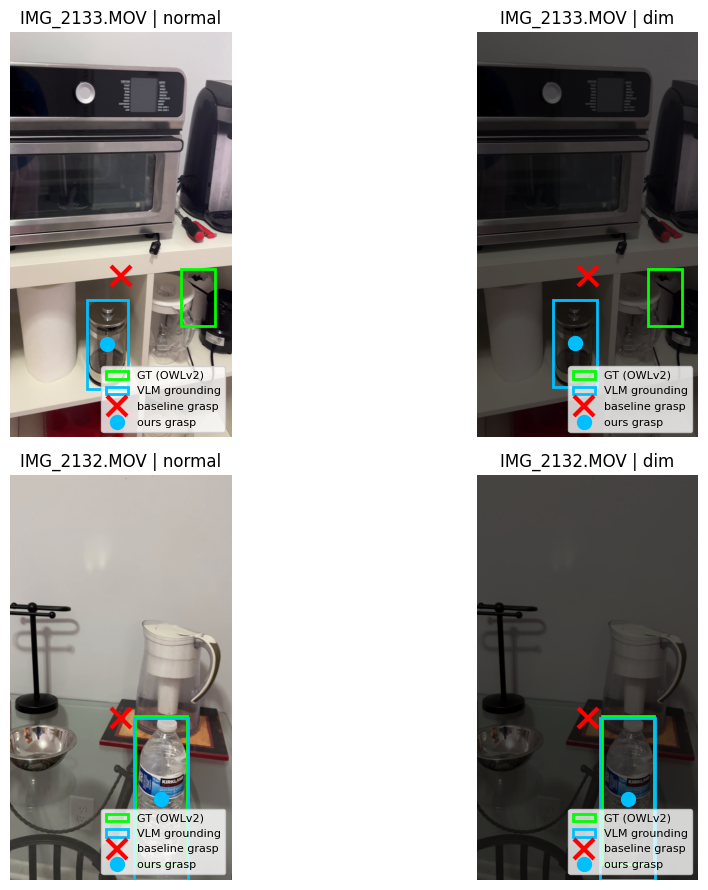

In [8]:
fig, axes = plt.subplots((len(viz) + 1) // 2, 2, figsize=(12, 4.5 * ((len(viz) + 1) // 2)), squeeze=False)
for ax, (title, img, gt, cb, co) in zip(axes.flat, viz):
    ax.imshow(img); ax.set_title(title); ax.axis("off")
    for box, c, lab in [(gt, "lime", "GT (OWLv2)"), (co["target_box"], "deepskyblue", "VLM grounding")]:
        if box: ax.add_patch(patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1], fill=False, ec=c, lw=2, label=lab))
    ax.plot(*cb["grasp_px"], "rx", ms=14, mew=3, label="baseline grasp")
    ax.plot(*co["grasp_px"], "o", c="deepskyblue", ms=10, label="ours grasp")
    ax.legend(loc="lower right", fontsize=8)
for ax in axes.flat[len(viz):]: ax.axis("off")
plt.tight_layout(); plt.show()

In [9]:
summary = df.groupby(["method", "lighting"])[["grasp_success", "IoU"]].mean().round(2)
print(summary, "\n")
print(df.groupby("method")[["grasp_success", "IoU"]].mean().round(2))

                                grasp_success   IoU
method                lighting                     
baseline (no context) dim                 0.0  0.00
                      normal              0.0  0.00
context-aware (ours)  dim                 0.5  0.42
                      normal              0.5  0.43 

                       grasp_success   IoU
method                                    
baseline (no context)            0.0  0.00
context-aware (ours)             0.5  0.43


## 5. Findings
- **Feasibility:** a frozen Video-LLM can turn a short walkthrough of an unseen home into structured context (surfaces/heights, objects, obstacles) and ground the task target in pixels — no retraining, only prompting.
- **Baseline vs. ours:** the preset-based baseline only succeeds when the new home happens to match the training layout; the context-aware layer adapts the grasp point and surface height per home (see summary table).
- **Lighting:** the *dim* condition shows how robust the grounding is to dynamic lighting; any IoU drop indicates where better perception (or exposure normalisation) is needed.
- **Limitations:** 2-D pixel targets only (a real system would lift them to 3-D with depth), OWLv2 boxes are pseudo ground truth, the low-level policy is scripted, and the number of homes is small.
- **Next steps:** add depth for 3-D grounding, feed the context into a learned policy (e.g. a VLA model) in a simulator such as Habitat/RoboCasa, and test more homes and clutter levels.